# Notebook 4 — SHAP Explainability

**Purpose:** Add the XAI layer so predictions are interpretable. SHAP is used because Sami et al. (2025) cite it as the right tool for making AIOps dashboards operationally useful, and the dissertation's Research Gap (Section 7C) identifies the lack of real-time visual explanations as the problem this work solves. We load the trained model and a **sample** of the test data (SHAP on the full set can be slow; ~2000 records is standard practice).

In [34]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import shap

ROOT = Path("../").resolve()
sys.path.insert(0, str(ROOT))
from src.preprocessing import prepare_for_training
from src.paths import MODELS_DIR, REPORTS_FIGURES

REPORTS_FIGURES.mkdir(parents=True, exist_ok=True)

### Load model and sample test data

We use a sample of about 2000 test records for SHAP so that computation stays tractable. Explaining the full test set is possible but slow; the sample is representative for global summaries and saves are reused by the dashboard.

In [35]:
X_train, X_val, X_test, y_train, y_val, y_test, feature_list, class_names, _ = prepare_for_training()
feature_list = list(feature_list)
class_names = list(class_names)
model = joblib.load(MODELS_DIR / "build_failure_model.pkl")

SAMPLE_SIZE = 2000
np.random.seed(42)
idx = np.random.choice(len(X_test), size=min(SAMPLE_SIZE, len(X_test)), replace=False)
X_sample = X_test.iloc[idx].copy()
y_sample = y_test[idx]
print(f"Using sample of {len(X_sample)} test records for SHAP.")

Using sample of 2000 test records for SHAP.


### Compute SHAP values

TreeExplainer is appropriate for XGBoost and is faster than KernelExplainer.

In [36]:
BACKGROUND_SIZE = min(100, len(X_sample))
X_background = X_sample.iloc[:BACKGROUND_SIZE]
explainer = shap.TreeExplainer(model, X_background)
shap_values_raw = explainer.shap_values(X_sample)
# Normalize: XGBoost multi-class returns (n_samples, n_features, n_classes); convert to list of (n_samples, n_features) per class
if isinstance(shap_values_raw, list):
    shap_values = shap_values_raw
else:
    arr = np.array(shap_values_raw)
    if arr.ndim == 3:
        # (n_samples, n_features, n_classes) -> list of (n_samples, n_features)
        shap_values = [arr[:, :, k] for k in range(arr.shape[2])]
    else:
        shap_values = [arr]
print("SHAP values: list of", len(shap_values), "arrays, each shape", shap_values[0].shape)

100%|===================| 7999/8000 [94:41<00:00]        

SHAP values: list of 4 arrays, each shape (2000, 9)


### Global summary (bar)

For each class, which features contributed most on average. We plot the mean |SHAP| per feature.

/var/folders/wq/g3c1d0v14n3cjt1tzxgd9w_80000gn/T/ipykernel_11144/15458713.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, feature_names=feature_list, class_names=class_names, plot_type="bar", show=False)


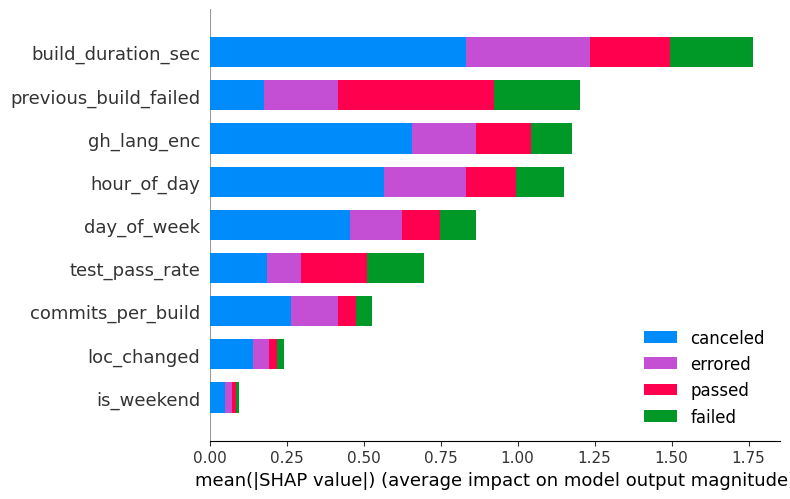

In [37]:
# Global summary bar: mean |SHAP| per feature (for each class)
shap.summary_plot(shap_values, X_sample, feature_names=feature_list, class_names=class_names, plot_type="bar", show=False)
import matplotlib.pyplot as plt
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "04_shap_summary_bar.png", dpi=150, bbox_inches="tight")
plt.show()

### Beeswarm plot (failed class)

For the "failed" class, show direction and magnitude of each feature's influence across all samples. This is the most information-rich plot for academic discussion.

/var/folders/wq/g3c1d0v14n3cjt1tzxgd9w_80000gn/T/ipykernel_11144/1343945953.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv_failed, X_sample, feature_names=feature_list, show=False)


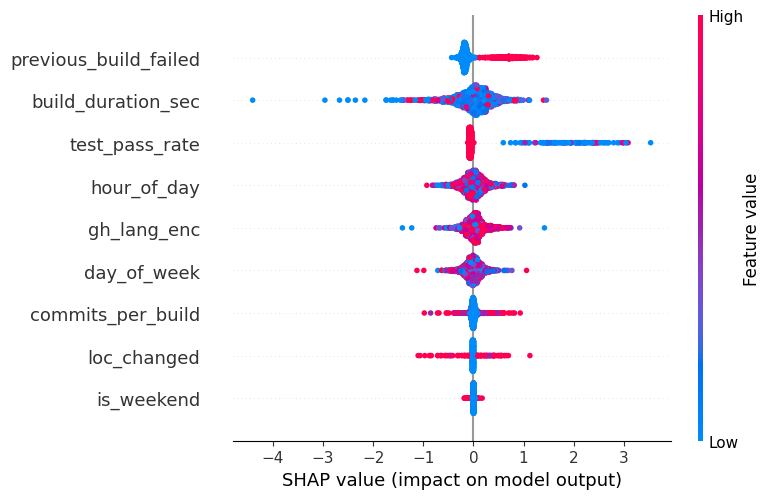

In [38]:
# Index of "failed" class
failed_idx = list(class_names).index("failed") if "failed" in class_names else 0
sv_failed = shap_values[failed_idx] if isinstance(shap_values, list) else shap_values
shap.summary_plot(sv_failed, X_sample, feature_names=feature_list, show=False)
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "04_shap_beeswarm_failed.png", dpi=150, bbox_inches="tight")
plt.show()

### Waterfall plot (one representative failed build)

Decompose the prediction for a single build step-by-step: how each feature pushed the probability up or down from the baseline.

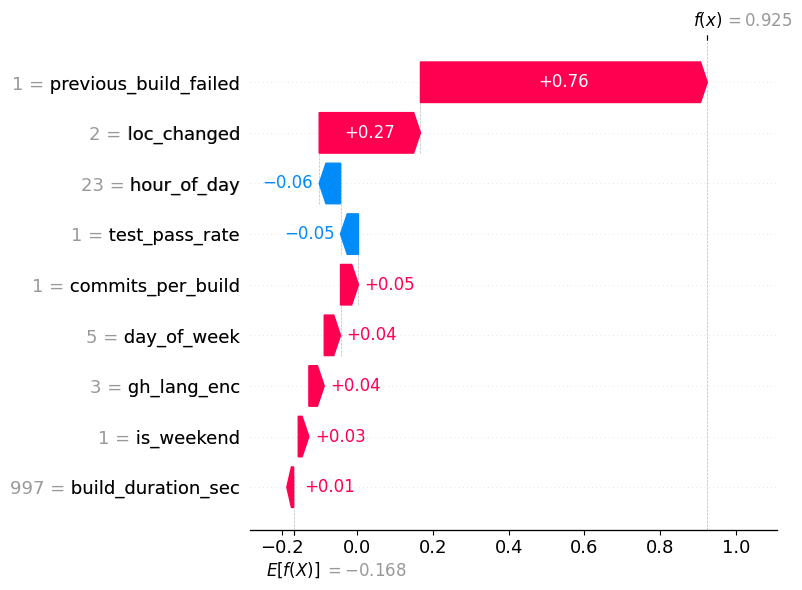

In [39]:
# Pick a representative failed build (true label = failed)
failed_mask = y_sample == failed_idx
if failed_mask.any():
    sample_idx = np.where(failed_mask)[0][0]
else:
    sample_idx = 0
# One row: values must be 1d (n_features,); base_values must be scalar
ev = explainer.expected_value
base_val = float(ev[failed_idx]) if hasattr(ev, "__len__") and not isinstance(ev, str) else float(ev)
vals_1d = np.asarray(shap_values[failed_idx][sample_idx]).flatten()
ex = shap.Explanation(
    values=vals_1d,
    base_values=base_val,
    data=X_sample.iloc[sample_idx].values,
    feature_names=feature_list,
)
shap.waterfall_plot(ex, show=False)
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "04_shap_waterfall_failed.png", dpi=150, bbox_inches="tight")
plt.show()

### Dependence plot (top feature)

How the top feature's value correlates with its SHAP impact. We use the first feature from importance or the failed-class summary.

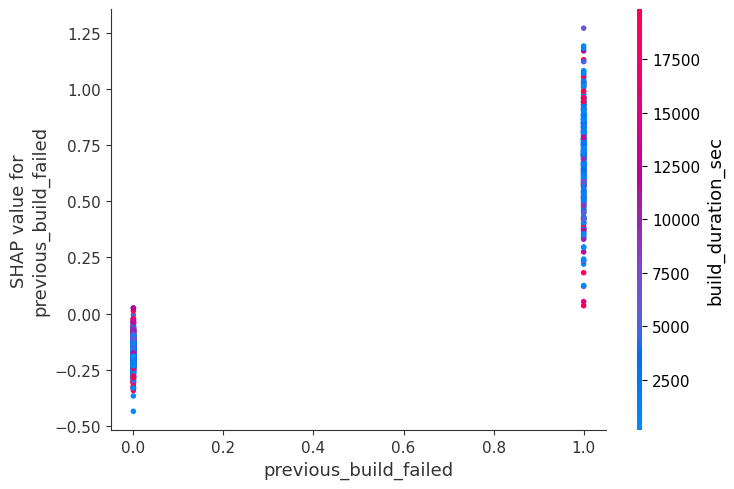

In [40]:
mean_abs = np.abs(sv_failed).mean(axis=0)
top_feat = feature_list[int(np.argmax(mean_abs))]
shap.dependence_plot(top_feat, sv_failed, X_sample, feature_names=feature_list, show=False)
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "04_shap_dependence_top.png", dpi=150, bbox_inches="tight")
plt.show()

### Force plot (one failed, one passed)

Force plot for one predicted-failed and one predicted-passed build to illustrate the contrast between outcomes.

In [41]:
preds = model.predict(X_sample)
# One predicted failed
pred_failed_idx = np.where(preds == failed_idx)[0]
pred_failed_idx = pred_failed_idx[0] if len(pred_failed_idx) else 0
# One predicted passed
passed_idx = list(class_names).index("passed") if "passed" in class_names else 0
pred_passed_idx = np.where(preds == passed_idx)[0]
pred_passed_idx = pred_passed_idx[0] if len(pred_passed_idx) else 0
# Force plots (HTML); we save as PNG by using matplotlib summary or just display
# shap.force_plot is HTML; for saving we use waterfall or show inline
print("Force plot (predicted failed) - run in Jupyter to see interactive HTML:")
shap.force_plot(
    explainer.expected_value[failed_idx] if isinstance(explainer.expected_value, np.ndarray) else explainer.expected_value,
    shap_values[failed_idx][pred_failed_idx] if isinstance(shap_values, list) else shap_values[pred_failed_idx],
    X_sample.iloc[pred_failed_idx],
    feature_names=feature_list,
)
print("\nForce plot (predicted passed):")
shap.force_plot(
    explainer.expected_value[passed_idx] if isinstance(explainer.expected_value, np.ndarray) else explainer.expected_value,
    shap_values[passed_idx][pred_passed_idx] if isinstance(shap_values, list) else shap_values[pred_passed_idx],
    X_sample.iloc[pred_passed_idx],
    feature_names=feature_list,
)

Force plot (predicted failed) - run in Jupyter to see interactive HTML:

Force plot (predicted passed):


### Save SHAP data for the dashboard

Save the explainer (or SHAP values and sample) and sample indices so the dashboard can load them without recomputing.

In [42]:
# Save SHAP values and sample; do not pickle explainer (recreate in dashboard from model + X_sample)
ev = explainer.expected_value
expected_value = np.asarray(ev).tolist() if hasattr(ev, "__len__") and not isinstance(ev, str) else [float(ev)]
shap_data = {
    "shap_values": shap_values,
    "X_sample": X_sample,
    "y_sample": y_sample,
    "sample_indices": idx,
    "feature_list": feature_list,
    "class_names": class_names,
    "expected_value": expected_value,
}
joblib.dump(shap_data, MODELS_DIR / "shap_data.joblib")
print("Saved shap_data.joblib (values, sample, expected_value) for dashboard.")

Saved shap_data.joblib (values, sample, expected_value) for dashboard.
